In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.insert(0, '/home/kat/Repos/SALSA/')

import numpy as np
from datetime import datetime

# # # # # # # # # # # # # # #
save = True
fp_type = 'morgan'
cnts = False
bits = 1024
r = 2
dist_type = 'euclidean'
# # # # # # # # # # # # # # #

today = datetime.today().strftime('%Y%m%d%H')

if cnts==False:
    c = 'bitv'
elif cnts==True:
    c = 'cntv'
    
if dist_type=='euclidean':
    d = 'eucnorm'
    
v = '_'.join(['baseline','2000n_extended',fp_type,c,f'{bits}b',f'{r}r',d])
tag = f'{today}_{v}'
print(tag)

2022050223_baseline_2000n_extended_morgan_bitv_1024b_2r_eucnorm


## 1) Load model UMAP for consistent ordering of coords (?) Calculate fps.

In [3]:
rdir = '/home/kat/Repos/SALSA/results/'
mdir = '/home/kat/Repos/SALSA/data/model_ready/'

In [5]:
# Which evaluation set? ...
# # # # # # # # # # # 
umap_tag = '2022041809_a04_12000n_extended_32neigh_mindist0pt1'
# # # # # # # # # # # 

import pandas as pd
from utilities.fp_utils import get_fps_in_parallel
import numpy as np
from sklearn import preprocessing

df = pd.read_csv(f'{rdir}umap_dfs/{umap_tag}.csv', usecols=["Smiles","Label","Atype"])
display(df)

fps = get_fps_in_parallel(df.Smiles,fp_type,counts=cnts,bits=bits,)
fps = np.stack(fps)

if dist_type=='euclidean':
    fps = preprocessing.normalize(fps, norm='l2', axis=1)
print(fps.shape)

,Smiles,Atype,Label
0,CC(C)N(C)CC(O)COc1ccccc1,Anc,0
1,O=C(CSc1nc[nH]n1)c1cc2ccccc2o1,Anc,1
2,Cc1cc(Br)ccc1OCCCCNC(C)(C)C,Anc,2
3,O=C(CCNC(=O)c1ccc(Cl)cc1)Nc1ccc(Cl)cc1F,Anc,3
4,CCCn1nc(-c2cn(Cc3ccc(Cl)c(Cl)c3)c3ccccc23)cc1C...,Anc,4
...,...,...,...
11995,CCOC(=O)N1CCN(C(=O)COC(=O)c2cccc(S(C)(=O)=O)c2...,Anc,11995
11996,COc1cc(C(C)=O)ccc1OCc1cc(C(=O)N2CCSCC2)no1,Anc,11996
11997,CC(C)Oc1c(C(C)C)c(O)c2c(=O)cc(-c3ccccc3)oc2c1C...,Anc,11997
11998,c1ccc(CC2NCCc3c2[nH]c2ccccc32)cc1,Anc,11998


(12000, 1024)


## 2) Calculate and plot UMAP projection.

In [12]:
import umap.umap_ as umap
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import random
def get_umap_coords(tag_emb, df, latents, n_neighs, min_dist, 
                    save_coords=True, save_plot=True, show_plot=True):
 
    rdir = '/home/kat/Repos/SALSA/results/'
    
    pt = str(min_dist).split('.')[1]
    tag_coords = '_'.join([tag_emb, f'{n_neighs}neigh', f'mindist0pt{pt}'])
    print(f"Tag is {tag_coords}!")
    
    umapper = umap.UMAP(n_neighbors=n_neighs, min_dist=min_dist, 
                        n_components=2, metric='euclidean')
    embedding = umapper.fit_transform(latents)

    df['x'] = embedding[:, 0]
    df['y'] = embedding[:, 1]

    if save_coords:
        csv_out = f'{rdir}umap_dfs/{tag_coords}.csv'
        df.to_csv(csv_out,index=False)
        print(f"Saved smiles and coords to {csv_out}!")
        
    sns.set_theme(style='ticks',font_scale=1.5)
    plt.figure(figsize=(10,10))
    sns.scatterplot(data=df[df['Atype']=='Aug'], x='x', y='y', hue='Atype', 
                    alpha=0.5, s=10, palette={'Aug':'red'})
    sns.scatterplot(data=df[df['Atype']=='Anc'], x='x', y='y', hue='Atype', 
                    alpha=1., s=7, palette={'Anc':'blue'})
        
    if save_plot:
        png_out = f'{rdir}umap_figs/{tag_coords}.png'
        plt.savefig(png_out, bbox_inches='tight')
        print(f"Saved umap plot to {png_out}!")
    if show_plot:
        plt.show()
        
    return df

Tag is 2022050223_baseline_2000n_extended_morgan_bitv_1024b_2r_eucnorm_32neigh_mindist0pt1!
Saved smiles and coords to /home/kat/Repos/SALSA/results/umap_dfs/2022050223_baseline_2000n_extended_morgan_bitv_1024b_2r_eucnorm_32neigh_mindist0pt1.csv!
Saved umap plot to /home/kat/Repos/SALSA/results/umap_figs/2022050223_baseline_2000n_extended_morgan_bitv_1024b_2r_eucnorm_32neigh_mindist0pt1.png!


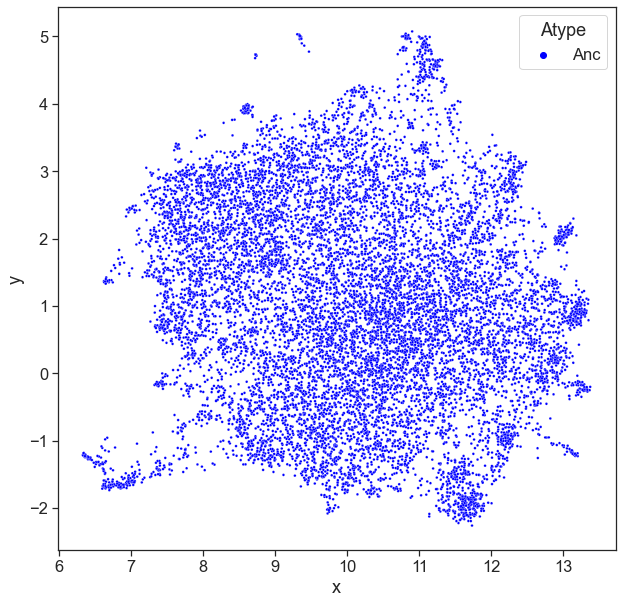

,Smiles,Atype,Label,x,y
0,CC(C)N(C)CC(O)COc1ccccc1,Anc,0,12.149898,1.840966
1,O=C(CSc1nc[nH]n1)c1cc2ccccc2o1,Anc,1,11.470901,-0.286956
2,Cc1cc(Br)ccc1OCCCCNC(C)(C)C,Anc,2,11.988086,1.320459
3,O=C(CCNC(=O)c1ccc(Cl)cc1)Nc1ccc(Cl)cc1F,Anc,3,10.340285,0.840382
4,CCCn1nc(-c2cn(Cc3ccc(Cl)c(Cl)c3)c3ccccc23)cc1C...,Anc,4,12.472317,-0.815997
...,...,...,...,...,...
11995,CCOC(=O)N1CCN(C(=O)COC(=O)c2cccc(S(C)(=O)=O)c2...,Anc,11995,8.638628,2.155555
11996,COc1cc(C(C)=O)ccc1OCc1cc(C(=O)N2CCSCC2)no1,Anc,11996,8.292439,2.516266
11997,CC(C)Oc1c(C(C)C)c(O)c2c(=O)cc(-c3ccccc3)oc2c1C...,Anc,11997,13.225757,0.951753
11998,c1ccc(CC2NCCc3c2[nH]c2ccccc32)cc1,Anc,11998,11.004727,3.303521


In [13]:
get_umap_coords(tag_emb=tag, df=df, latents=fps, n_neighs=32, min_dist=0.1, 
               save_coords=True, save_plot=True, show_plot=True)